# AR Model Notebook

This notebook covers:
1. **Setup** - Imports and helper functions
2. **Simulation** - Generating synthetic hierarchical AR(1) data and checking stationarity
3. **Model 1: AR(1) on Synthetic Data** - Fitting `ar_1.stan` to simulated data
4. **Model 2: Hierarchical AR (ICAR Prior) on Synthetic Data** - Fitting `ar_1_hierarchical.stan`
5. **Model 3: AR(1) on CTA Red Line Data** - Fitting `ar_1_cta.stan` to real weekly ridership

---
## 1. Setup

Imports and CmdStan path configuration.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

In [3]:
def sim_ar_model(alpha, beta, sigma, T, initial=0, seed=None):
    """Simulate an AR(1) process.

    Parameters
    ----------
    alpha : float
        Intercept.
    beta : float
        Lag-1 coefficient.
    sigma : float
        Innovation standard deviation.
    T : int
        Number of time steps to simulate.
    initial : float
        Initial value for Y[0].
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    Y : array of shape (T,)
        Simulated time series.
    """
    np.random.seed(seed)
    assert T >= 1

    Y = np.zeros(T)
    epsilon = np.random.normal(0, sigma, size=T)

    Y[0] = initial

    for t in range(1, T):
        Y[t] = alpha + beta * Y[t - 1] + epsilon[t]
    return Y

## 2. Simulate AR(1) Data

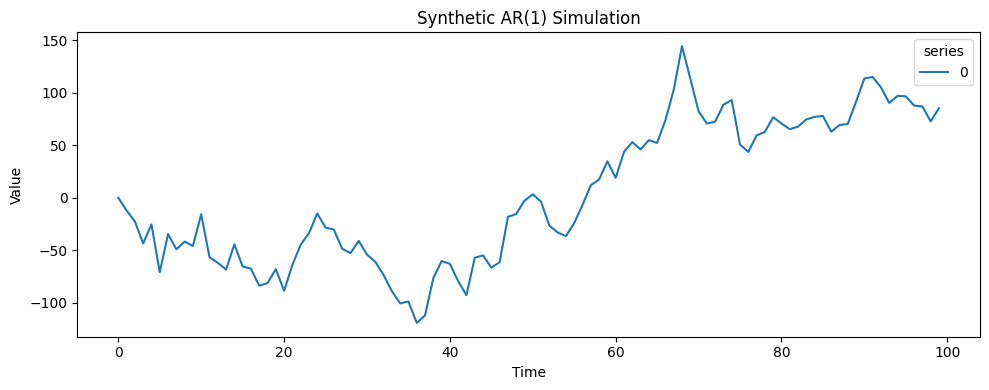

In [21]:
T = 100
alpha = 0
beta= 0.98
sigma = 20

y = sim_ar_model(alpha = alpha, beta = beta, sigma = 20, T = T, seed = 1)

df_sim = pd.DataFrame(y)
df_sim["t"] = range(T)
df_sim_long = df_sim.melt(id_vars="t", var_name="series", value_name="value")

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_sim_long, x="t", y="value", hue="series")
plt.title("Synthetic AR(1) Simulation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 3. Model 1: AR(1) on Simulated Data

In [22]:
stan_data_ar1_sim = {
    "T": T,
    "y": y
}

ar_mod = CmdStanModel(stan_file="ar_1.stan")
ar_mod_post = ar_mod.sample(data=stan_data_ar1_sim)
print(ar_mod_post.diagnose())

18:01:55 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

18:01:56 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### 3.1 Parameter Recovery

In [24]:
ar_mod_params = ar_mod_post.stan_variables()

print("True alpha:", alpha)
print("Estimated alpha:", ar_mod_params["alpha"].mean(axis=0))
print()
print("True beta:", beta)
print("Estimated beta:", ar_mod_params["beta"].mean(axis=0))
print()
print("True sigma:", sigma)
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))

True alpha: 0
Estimated alpha: 0.9052837317187548

True beta: 0.98
Estimated beta: 0.9732624959924999

True sigma: 20
Estimated sigma: 17.891803323749997


In [17]:
print(ar_mod_post.summary())

            Mean      MCSE    StdDev       MAD          5%         50%  \
lp__  -331.60400  0.028463  1.273420  1.037240 -334.066000 -331.285000   
alpha    1.91480  0.036918  1.997090  1.999990   -1.288680    1.901320   
beta     0.97951  0.000456  0.024198  0.023889    0.939005    0.979751   
sigma   17.99950  0.026867  1.367720  1.330240   15.903700   17.903100   

             95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -330.22200   1912.10   2790.88     9019.35  1.00192  
alpha    5.20791   2936.95   2968.19    13853.50  1.00129  
beta     1.01880   2827.60   2860.88    13337.70  1.00168  
sigma   20.27880   2664.83   2513.38    12569.90  1.00165  


## 4. Simulate Network AR(1) Data

In [44]:
def sim_ar_net_model(gamma, delta, c, beta, W, tau, alpha, T, initial=None, seed=None):
    """Simulate a network AR(1) with CAR-structured innovations.

    Model:
        Y_i(t) = c_i + beta_i * Y_i(t-1) + epsilon(t)
        epsilon(t) ~ MVN(0, Sigma)
        Sigma = (tau * (D - rho * W))^{-1}     [proper CAR]

    Parameters
    ----------
    c : array of shape (K,)
        Node-specific intercepts.
    beta : array of shape (K,)
        Node-specific AR(1) coefficients.
    W : array of shape (K, K)
        Adjacency matrix (symmetric, zero diagonal).
    tau : float
    alpha : float (0 < alpha < 1)
        Controls the amount of spatial correlation
    T : int
        Number of time periods
    initial : array of shape (K,) or None
    seed : int or None

    Returns
    -------
    Y : array of shape (T, K)
        Simulated multivariate time series.
    Sigma : array of shape (K, K)
        Innovation covariance matrix used.
    """

    np.random.seed(seed)
    K = len(c)
    assert W.shape == (K, K)
    assert T >= 1

    # Build precision matrix (Q)
    D = np.diag(W.sum(axis=1))
    Q = tau * (D - alpha * W)
    Sigma = np.linalg.inv(Q)

    # Simulate
    Y = np.zeros((T, K))
    if initial is not None:
        Y[0] = initial

    epsilon = np.random.multivariate_normal(np.zeros(K), Sigma, size=T)

    for t in range(1, T):
        Y[t] = gamma + delta * Y[t - 1] + c + beta * Y[t - 1] + epsilon[t]

    return Y, Sigma

In [ ]:
# 5-node linear chain: 1--2--3--4--5
K = 5
W = np.zeros((K, K))
for i in range(K - 1):
    W[i, i + 1] = 1
    W[i + 1, i] = 1

print("Adjacency matrix W:")
print(W)

# Simulation parameters
c_net = np.array([1.0, 1.5, 1.7, 1.5, 1.0])       # full node intercepts
beta_net = np.array([0.7, 0.55, 0.7, 0.45, 0.9])   # full node AR coefficients
gamma_net = c_net.mean()                             # population intercept (hierarchical mean)
delta_net = beta_net.mean()                          # population AR coefficient (hierarchical mean)
alpha_net = 0.8   # spatial correlation (0 < alpha < 1)
tau_net = 1.0     # precision scale
T_net = 200

Y_net, Sigma_net = sim_ar_net_model(
    delta=0, gamma=0,
    c=c_net, beta=beta_net, W=W,
    tau=tau_net, alpha=alpha_net, T=T_net, seed=42
)

print(f"\nSimulated data shape: {Y_net.shape}")
print(f"\nPopulation intercept (gamma): {gamma_net}")
print(f"Population coefficient (delta): {delta_net}")
print(f"\nInnovation covariance Sigma:")
print(np.round(Sigma_net, 3))

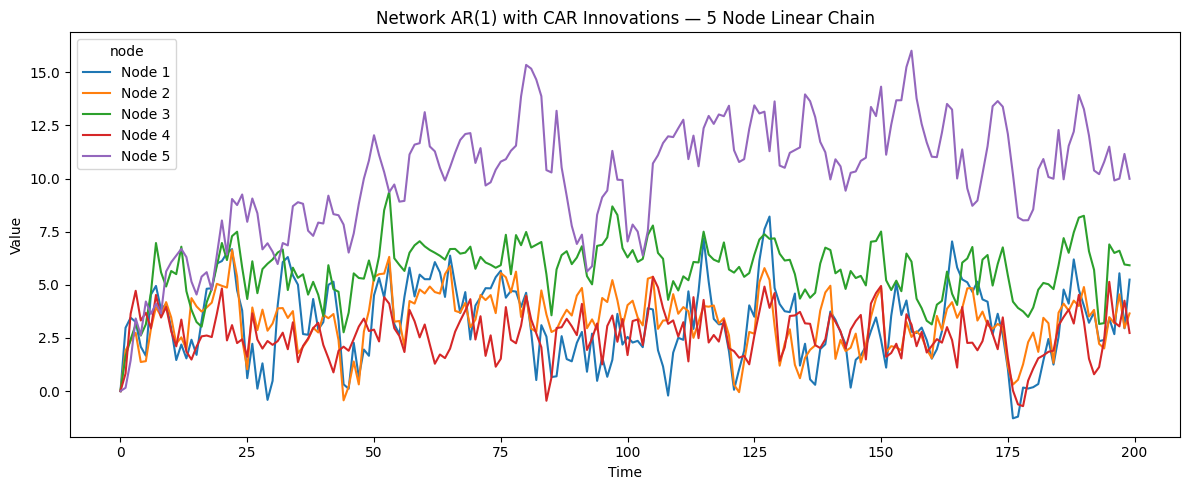

In [64]:
# Plot all 5 nodes
df_net = pd.DataFrame(Y_net, columns=[f"Node {i+1}" for i in range(K)])
df_net["t"] = range(T_net)
df_net_long = df_net.melt(id_vars="t", var_name="node", value_name="value")

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_net_long, x="t", y="value", hue="node")
plt.title("Network AR(1) with CAR Innovations — 5 Node Linear Chain")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 4. Model 2: AR(1) on Simulated Network Data

In [65]:
stan_data_hier = {
    "T": T_net,
    "K": len(c_net),
    "Y": Y_net
}

ar_mod_hier = CmdStanModel(stan_file="ar_1_hierarchical.stan")
ar_mod_hier_post = ar_mod_hier.sample(data=stan_data_hier)
print(ar_mod_hier_post.diagnose())

18:55:15 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

18:56:10 - cmdstanpy - INFO - CmdStan done processing.
18:56:10 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'ar_1_hierarchical.stan', line 34, column 2 to column 38)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical.stan', line 39, column 6 to column 89)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical.stan', line 39, column 6 to column 89)
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'ar_1_hierarchical.stan', line 24, column 2 to column 28)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'ar_1_hierarchical.stan', line 24, column 2 to column 28)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical.stan', line 39, column 6 to column 89)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
ar_mod_hier_params = ar_mod_hier_post.stan_variables()

print("=== Population Level ===")
print("True gamma (pop intercept):", gamma_net)
print("Estimated gamma:", ar_mod_hier_params["gamma"].mean(axis=0))
print()
print("True delta (pop coefficient):", delta_net)
print("Estimated delta:", ar_mod_hier_params["delta"].mean(axis=0))
print()
print("=== Node Level ===")
print("True c (node intercepts):", c_net)
print("Estimated c:", ar_mod_hier_params["c"].mean(axis=0))
print()
print("True beta (node coefficients):", beta_net)
print("Estimated beta:", ar_mod_hier_params["beta"].mean(axis=0))
print()
print("=== Innovation SD ===")
print("True sigma (diag of Sigma):", np.sqrt(np.diag(Sigma_net)))
print("Estimated sigma:", ar_mod_hier_params["sigma"].mean(axis=0))

In [ ]:
print(ar_mod_hier_post.summary())

## 5. Model 3: Hierarchical AR(1) with ICAR Prior on Simulated Network Data

This model extends the hierarchical AR(1) by replacing the independent normal priors on node deviations with an **Intrinsic Conditional Autoregressive (ICAR)** prior. This encourages neighboring nodes to have similar intercepts and AR coefficients, leveraging the network structure.

Model:
- $c_k = \gamma + \phi^c_k$, where $\phi^c$ has an ICAR prior
- $\beta_k = \delta + \phi^\beta_k$, where $\phi^\beta$ has an ICAR prior
- $Y_{t,k} \sim \text{Normal}(c_k + \beta_k Y_{t-1,k},\; \sigma_k)$

In [ ]:
# Build edge list from adjacency matrix (node1[i] < node2[i])
node1 = []
node2 = []
for i in range(K):
    for j in range(i + 1, K):
        if W[i, j] == 1:
            node1.append(i + 1)  # Stan is 1-indexed
            node2.append(j + 1)

N_edges = len(node1)
print(f"Number of edges: {N_edges}")
print(f"Edge list: {list(zip(node1, node2))}")

stan_data_icar = {
    "T": T_net,
    "K": K,
    "Y": Y_net,
    "N_edges": N_edges,
    "node1": node1,
    "node2": node2
}

In [ ]:
ar_mod_icar = CmdStanModel(stan_file="ar_1_hierarchical_icar.stan")
ar_mod_icar_post = ar_mod_icar.sample(data=stan_data_icar)
print(ar_mod_icar_post.diagnose())

### 5.1 Parameter Recovery

In [ ]:
ar_mod_icar_params = ar_mod_icar_post.stan_variables()

print("=== Population Level ===")
print("True gamma (pop intercept):", gamma_net)
print("Estimated gamma:", ar_mod_icar_params["gamma"].mean(axis=0))
print()
print("True delta (pop coefficient):", delta_net)
print("Estimated delta:", ar_mod_icar_params["delta"].mean(axis=0))
print()
print("=== Node Level ===")
print("True c (node intercepts):", c_net)
print("Estimated c:", ar_mod_icar_params["c"].mean(axis=0))
print()
print("True beta (node coefficients):", beta_net)
print("Estimated beta:", ar_mod_icar_params["beta"].mean(axis=0))
print()
print("=== Spatial Deviations ===")
print("True phi_c (c - gamma):", c_net - gamma_net)
print("Estimated phi_c:", ar_mod_icar_params["phi_c"].mean(axis=0))
print()
print("True phi_beta (beta - delta):", beta_net - delta_net)
print("Estimated phi_beta:", ar_mod_icar_params["phi_beta"].mean(axis=0))
print()
print("=== Innovation SD ===")
print("True sigma (diag of Sigma):", np.sqrt(np.diag(Sigma_net)))
print("Estimated sigma:", ar_mod_icar_params["sigma"].mean(axis=0))

In [ ]:
print(ar_mod_icar_post.summary())